# Exploratory Data Analysis (EDA) - Brazilian E-Commerce Public Dataset (Olist)
**Mục tiêu:** Khám phá, đánh giá chất lượng và tìm ra các pattern cơ bản của bộ dữ liệu Olist để chuẩn bị cho việc xây dựng Data Model và Dashboard trên Power BI.

## 0. Import Thư Viện 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Datasets
Đọc các file CSV từ bộ dữ liệu OLIST.

In [2]:
path = "./data/OLIST/raw/" 

# Đọc các bảng dữ liệu chính
orders = pd.read_csv(path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("Data loaded successfully!")

Data loaded successfully!


## 2. Exploratory Data Analysis (EDA)
Kiểm tra số lượng dòng, cột và tỷ lệ missing values trong của tất cả các bảng để có chiến lược làm sạch.

In [3]:
all_tables = {
    "Orders": orders,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Products": products,
    "Customers": customers,
    "Sellers": sellers,
    "Translation": translation
}

def data_overview(tables_dict):
    print("=== TỔNG QUAN KÍCH THƯỚC BỘ DỮ LIỆU ===\n")
    overview_data = []
    for name, df in tables_dict.items():
        rows, cols = df.shape
        overview_data.append({"Tên Bảng": name, "Số Dòng": rows, "Số Cột": cols})
    
    overview_df = pd.DataFrame(overview_data)
    print(overview_df.to_string(index=False))
    print("\n" + "=" * 55 + "\n")

def check_all_missing_values(tables_dict):
    print("=== BÁO CÁO KIỂM TRA GIÁ TRỊ THIẾU TOÀN BỘ DATASET ===\n")
    for name, df in tables_dict.items():
        missing = df.isnull().sum()
        missing_percent = (missing / len(df)) * 100
        missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_percent})
        
        has_missing = missing_df[missing_df['Missing Values'] > 0]
        
        if not has_missing.empty:
            print(f"--- Bảng: {name} ---")
            print(has_missing.sort_values(by='Percentage (%)', ascending=False))
            print("-" * 40 + "\n")
        else:
            print(f"--- Bảng: {name} --- SẠCH (0% Missing)!")
            print("-" * 40 + "\n")

### 2.1 Overview of Data

In [4]:
data_overview(all_tables)

=== TỔNG QUAN KÍCH THƯỚC BỘ DỮ LIỆU ===

      Tên Bảng  Số Dòng  Số Cột
        Orders    99441       8
   Order Items   112650       7
Order Payments   103886       5
 Order Reviews    99224       7
      Products    32951       9
     Customers    99441       5
       Sellers     3095       4
   Translation       71       2




### 2.2 Missing Values Analysis

In [5]:
check_all_missing_values(all_tables)

=== BÁO CÁO KIỂM TRA GIÁ TRỊ THIẾU TOÀN BỘ DATASET ===

--- Bảng: Orders ---
                               Missing Values  Percentage (%)
order_delivered_customer_date            2965        2.981668
order_delivered_carrier_date             1783        1.793023
order_approved_at                         160        0.160899
----------------------------------------

--- Bảng: Order Items --- SẠCH (0% Missing)!
----------------------------------------

--- Bảng: Order Payments --- SẠCH (0% Missing)!
----------------------------------------

--- Bảng: Order Reviews ---
                        Missing Values  Percentage (%)
review_comment_title             87656       88.341530
review_comment_message           58247       58.702532
----------------------------------------

--- Bảng: Products ---
                            Missing Values  Percentage (%)
product_category_name                  610        1.851234
product_name_lenght                    610        1.851234
product_description_l

PLOTTING EDA (EXPLORATORY DATA ANALYSIS) VISUALIZATIONS...



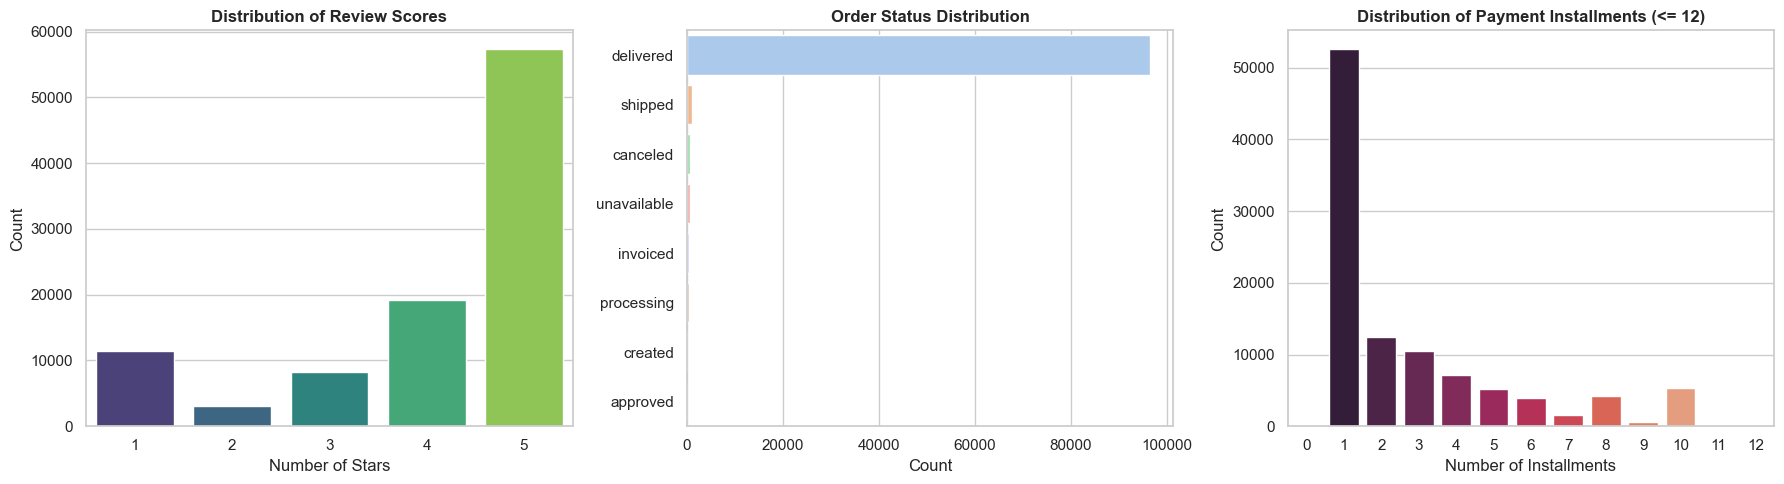

In [6]:
print("PLOTTING EDA (EXPLORATORY DATA ANALYSIS) VISUALIZATIONS...\n")

# Set plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of Review Scores
sns.countplot(data=all_tables['Order Reviews'], x='review_score', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Review Scores', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Stars')
axes[0].set_ylabel('Count')

# 2. Distribution of Order Status
sns.countplot(data=all_tables['Orders'], y='order_status', palette='pastel', 
              order=all_tables['Orders']['order_status'].value_counts().index, ax=axes[1])
axes[1].set_title('Order Status Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

# 3. Distribution of Payment Installments
# Limit to 1–12 installments to avoid long tails from outliers (e.g., 24 installments)
sns.countplot(
    data=all_tables['Order Payments'][all_tables['Order Payments']['payment_installments'] <= 12], 
    x='payment_installments', 
    palette='rocket', 
    ax=axes[2]
)
axes[2].set_title('Distribution of Payment Installments (<= 12)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Installments')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Kết luận nhanh

Dựa vào các biểu đồ phân phối cơ bản ở trên, chúng ta có thể bước đầu phác họa "bức tranh tổng quan" về nền tảng thương mại điện tử Olist như sau:

* **Sự phân cực trong Trải nghiệm Khách hàng (Review Scores):** Mức điểm 5 sao chiếm ưu thế tuyệt đối, cho thấy sự hài lòng chung của người tiêu dùng là rất cao. Tuy nhiên, **tỷ lệ đánh giá 1 sao cũng chiếm một phần không nhỏ**, tạo ra sự phân hóa rõ rệt. Đây là tín hiệu "cảnh báo đỏ" cần được đào sâu ở phần Dashboard (VD: Điểm 1 sao có sự tương quan mật thiết với các đơn hàng giao trễ hay không?).
* **Độ ổn định của Chuỗi cung ứng (Order Status):** Áp đảo hoàn toàn trong tập dữ liệu là các đơn hàng ở trạng thái **'Delivered' (Đã giao thành công)**, minh chứng cho một hệ thống vận hành và kho vận tương đối ổn định. Dù vậy, các trạng thái ngoại lệ (như `Canceled` hay `Unavailable`) vẫn sẽ được giữ lại để làm trọng tâm phân tích nhằm tối ưu hóa tỷ lệ chuyển đổi.
* **Hành vi Thanh toán cốt lõi (Payment Installments):** Khách hàng có xu hướng đặc biệt ưa chuộng **thanh toán trả đứt (1 kỳ)** thay vì trả góp dài hạn. Điều này mở ra giả thuyết rằng phần lớn các giao dịch trên Olist có giá trị (Ticket Size) vừa và nhỏ, hoặc thói quen tiêu dùng tại thị trường này ít lạm dụng đòn bẩy tín dụng.

**Tiểu kết:** Dữ liệu thô đã bắt đầu "kể" những câu chuyện đầu tiên. Với bộ dữ liệu đã được làm sạch và dọn dẹp kỹ lưỡng, chúng ta đã hoàn toàn sẵn sàng tiến bước vào **Power BI** để thực hiện các phép phân tích đa chiều chuyên sâu!


## 3. Preprocessing & Data Cleaning
Dựa trên báo cáo Missing Values, chúng ta áp dụng chiến lược sau:
1. **Ép kiểu dữ liệu (Type Casting):** Chuyển các cột thời gian từ chuỗi (string) sang định dạng `datetime`.
2. **Bảng Orders:** Giữ nguyên các giá trị thiếu (NaT) ở các cột ngày tháng, vì đây mang ý nghĩa nghiệp vụ (đơn bị hủy/chưa giao).
3. **Bảng Order Reviews:** Điền các bình luận bị thiếu (58% - 88%) bằng chuỗi nhận diện.
4. **Bảng Products:** Xử lý 610 sản phẩm thiếu danh mục và loại bỏ 2 sản phẩm bị lỗi thiếu hoàn toàn kích thước vật lý.

In [7]:
print("ĐANG THỰC HIỆN TIỀN XỬ LÝ DỮ LIỆU...\n")

# --- 3.1. Chuyển đổi định dạng Datetime cho bảng Orders và Reviews ---
datetime_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 
                        'order_delivered_carrier_date', 'order_delivered_customer_date', 
                        'order_estimated_delivery_date']

for col in datetime_cols_orders:
    all_tables['Orders'][col] = pd.to_datetime(all_tables['Orders'][col])

all_tables['Order Reviews']['review_creation_date'] = pd.to_datetime(all_tables['Order Reviews']['review_creation_date'])
all_tables['Order Reviews']['review_answer_timestamp'] = pd.to_datetime(all_tables['Order Reviews']['review_answer_timestamp'])

print("Mục 1 & 2: Đã ép kiểu dữ liệu các cột thời gian sang 'datetime'. Các giá trị thiếu (NaT) trong bảng Orders được giữ nguyên hợp lý theo nghiệp vụ.")


# --- 3.2. Làm sạch bảng Order Reviews (Xử lý 88% và 58% Missing) ---
all_tables['Order Reviews']['review_comment_title'].fillna('No Title', inplace=True)
all_tables['Order Reviews']['review_comment_message'].fillna('No Comment', inplace=True)

print("Mục 3: Đã điền thành công các chuỗi nhận diện ('No Title', 'No Comment') cho các bình luận bị thiếu trong bảng Order Reviews.")


# --- 3.3. Làm sạch bảng Products (Xử lý 1.85% Missing Category và 2 dòng lỗi kích thước) ---
# Điền "Others" cho 610 sản phẩm thiếu tên danh mục
all_tables['Products']['product_category_name'].fillna('others', inplace=True)

# Xóa 2 dòng bị thiếu trọng lượng/kích thước (tỷ lệ 0.006% quá nhỏ, an toàn để drop)
all_tables['Products'].dropna(subset=['product_weight_g', 'product_length_cm', 
                                      'product_height_cm', 'product_width_cm'], inplace=True)

print("Mục 4: Đã gán danh mục 'others' cho 610 sản phẩm và loại bỏ 2 sản phẩm bị khuyết hoàn toàn kích thước vật lý.")


print("\n🎉 HOÀN TẤT BƯỚC 3: TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU!")
print("-" * 60)

# In ra kiểm tra nhanh kết quả để xác thực
print(f"Kiểm tra chéo: Số lượng comment bị thiếu hiện tại = {all_tables['Order Reviews']['review_comment_message'].isnull().sum()}")
print(f"Kiểm tra chéo: Số lượng category bị thiếu hiện tại = {all_tables['Products']['product_category_name'].isnull().sum()}")

ĐANG THỰC HIỆN TIỀN XỬ LÝ DỮ LIỆU...

Mục 1 & 2: Đã ép kiểu dữ liệu các cột thời gian sang 'datetime'. Các giá trị thiếu (NaT) trong bảng Orders được giữ nguyên hợp lý theo nghiệp vụ.
Mục 3: Đã điền thành công các chuỗi nhận diện ('No Title', 'No Comment') cho các bình luận bị thiếu trong bảng Order Reviews.
Mục 4: Đã gán danh mục 'others' cho 610 sản phẩm và loại bỏ 2 sản phẩm bị khuyết hoàn toàn kích thước vật lý.

🎉 HOÀN TẤT BƯỚC 3: TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU!
------------------------------------------------------------
Kiểm tra chéo: Số lượng comment bị thiếu hiện tại = 0
Kiểm tra chéo: Số lượng category bị thiếu hiện tại = 0


## 4. Feature Engineering 

Ở bước này, chúng ta sẽ tạo thêm các cột mới dựa trên logic nghiệp vụ của 5 chủ đề:
1. **Logistics:** Tính số ngày giao hàng, gắn cờ đơn hàng trễ hạn.
2. **Thời gian:** Tách giờ, thứ trong tuần từ timestamp để phân tích hành vi mua sắm.
3. **Sản phẩm:** Dịch tên danh mục sang Tiếng Anh.
4. **Thanh toán:** Chia nhóm số kỳ trả góp.
5. **Khách hàng:** Tính độ dài bình luận để đánh giá mức độ hài lòng.

In [ ]:
# --- 4.1. Xử lý bảng Orders (Phục vụ Chủ đề 1 & 3) ---

# Tách các thành phần thời gian để phân tích tăng trưởng và khung giờ (Mục tiêu 1.1, 1.2, 2.3)
all_tables['Orders']['order_purchase_year'] = all_tables['Orders']['order_purchase_timestamp'].dt.year
all_tables['Orders']['order_purchase_month'] = all_tables['Orders']['order_purchase_timestamp'].dt.month
all_tables['Orders']['order_purchase_dayofweek'] = all_tables['Orders']['order_purchase_timestamp'].dt.day_name()
all_tables['Orders']['order_purchase_hour'] = all_tables['Orders']['order_purchase_timestamp'].dt.hour

# Tính thời gian giao hàng thực tế và gắn cờ trễ hạn (Mục tiêu 3.1, 3.2, 5.1)
all_tables['Orders']['delivery_time_days'] = (all_tables['Orders']['order_delivered_customer_date'] - 
                                              all_tables['Orders']['order_purchase_timestamp']).dt.days

# Tạo cột is_late: 1 nếu giao sau ngày dự kiến, 0 nếu đúng hạn
all_tables['Orders']['is_late'] = (all_tables['Orders']['order_delivered_customer_date'] > 
                                   all_tables['Orders']['order_estimated_delivery_date']).astype(int)

print("Đã tạo xong các cột thời gian và chỉ số giao hàng cho bảng Orders.")

Đã tạo xong các cột thời gian và chỉ số giao hàng cho bảng Orders.


In [9]:
# --- 4.2. Xử lý bảng Products & Items (Phục vụ Chủ đề 3 & 4) ---

# Dịch tên danh mục sang Tiếng Anh bằng cách Merge với bảng Translation (Mục tiêu 4.1)
all_tables['Products'] = pd.merge(all_tables['Products'], all_tables['Translation'], 
                                  on='product_category_name', how='left')
all_tables['Products']['product_category_name_english'].fillna('others', inplace=True)

# Tính tỷ trọng phí vận chuyển trên mỗi món hàng (Mục tiêu 3.3)
all_tables['Order Items']['freight_ratio'] = (all_tables['Order Items']['freight_value'] / 
                                              (all_tables['Order Items']['price'] + all_tables['Order Items']['freight_value']))

print("Đã hoàn thành dịch tên danh mục và tính tỷ trọng phí vận chuyển.")

Đã hoàn thành dịch tên danh mục và tính tỷ trọng phí vận chuyển.


In [10]:
# --- 4.3. Xử lý bảng Payments (Phục vụ Chủ đề 2) ---

# Chia nhóm số kỳ trả góp để dễ trực quan hóa (Mục tiêu 2.2)
def categorize_installments(n):
    if n <= 1: return 'Single Payment'
    if n <= 6: return 'Short-term (2-6)'
    if n <= 12: return 'Mid-term (7-12)'
    return 'Long-term (>12)'

all_tables['Order Payments']['installment_type'] = all_tables['Order Payments']['payment_installments'].apply(categorize_installments)

print("Đã phân nhóm xong các kỳ trả góp khách hàng.")

Đã phân nhóm xong các kỳ trả góp khách hàng.


In [11]:
# --- 4.4. Xử lý bảng Reviews (Phục vụ Chủ đề 5) ---

# Tính độ dài bình luận và kiểm tra xem khách có viết chữ không (Mục tiêu 5.3)
all_tables['Order Reviews']['comment_length'] = all_tables['Order Reviews']['review_comment_message'].apply(lambda x: len(str(x)) if x != 'No Comment' else 0)
all_tables['Order Reviews']['has_comment'] = all_tables['Order Reviews']['review_comment_message'].apply(lambda x: 1 if x != 'No Comment' else 0)

print("Đã đo lường xong độ dài phản hồi của khách hàng.")
print("\n" + "="*50)
print("TẤT CẢ CÁC ĐẶC TRƯNG ĐÃ ĐƯỢC CHUẨN BỊ SẴN SÀNG CHO POWER BI!")

Đã đo lường xong độ dài phản hồi của khách hàng.

TẤT CẢ CÁC ĐẶC TRƯNG ĐÃ ĐƯỢC CHUẨN BỊ SẴN SÀNG CHO POWER BI!


## 5. Sanity Check & Data Validation

Trước khi xuất file, chúng ta cần:
1. **Loại bỏ trùng lặp (Duplicates):** Đảm bảo không có các dòng dữ liệu bị nhân bản do lỗi hệ thống.
2. **Xử lý dữ liệu ngoại lai (Outliers/Errors) cơ bản:** Ví dụ, thời gian giao hàng (`delivery_time_days`) không thể là số âm (ngày giao < ngày mua). Nếu có, đó là lỗi hệ thống và cần loại bỏ hoặc xử lý.

In [12]:
print("ĐANG KIỂM TRA TÍNH HỢP LỆ CỦA DỮ LIỆU...\n")

# --- 5.1. Loại bỏ các dòng trùng lặp (Drop Duplicates) ---
for name, df in all_tables.items():
    initial_rows = len(df)
    df.drop_duplicates(inplace=True)
    dropped_rows = initial_rows - len(df)
    if dropped_rows > 0:
        print(f"Bảng {name}: Đã xóa {dropped_rows} dòng trùng lặp.")
    else:
        print(f"Bảng {name}: Không có dòng trùng lặp.")

print("-" * 40)

# --- 5.2. Kiểm tra logic nghiệp vụ (Thời gian giao hàng âm) ---
orders_df = all_tables['Orders']

# Tìm các đơn hàng có ngày giao hàng sớm hơn ngày mua (lỗi logic)
negative_delivery = orders_df[orders_df['delivery_time_days'] < 0]

if not negative_delivery.empty:
    print(f"⚠️ CẢNH BÁO: Phát hiện {len(negative_delivery)} đơn hàng có thời gian giao < 0 ngày (lỗi logic). Đang tiến hành loại bỏ...")
    # Giữ lại những dòng có thời gian giao >= 0 hoặc bị NaT (chưa giao)
    all_tables['Orders'] = orders_df[(orders_df['delivery_time_days'] >= 0) | (orders_df['delivery_time_days'].isnull())]
    print(f"Đã dọn dẹp các đơn hàng lỗi thời gian.")
else:
    print("Logic thời gian giao hàng hợp lý (Không có ngày âm).")

print("\n🎉 HOÀN TẤT BƯỚC 5: KIỂM TRA CHÉO DỮ LIỆU!")

ĐANG KIỂM TRA TÍNH HỢP LỆ CỦA DỮ LIỆU...

Bảng Orders: Không có dòng trùng lặp.
Bảng Order Items: Không có dòng trùng lặp.
Bảng Order Payments: Không có dòng trùng lặp.
Bảng Order Reviews: Không có dòng trùng lặp.
Bảng Products: Không có dòng trùng lặp.
Bảng Customers: Không có dòng trùng lặp.
Bảng Sellers: Không có dòng trùng lặp.
Bảng Translation: Không có dòng trùng lặp.
----------------------------------------
Logic thời gian giao hàng hợp lý (Không có ngày âm).

🎉 HOÀN TẤT BƯỚC 5: KIỂM TRA CHÉO DỮ LIỆU!


## 6. Export Data

Lưu toàn bộ các bảng trong dictionary `all_tables` ra các file `.csv` với tiền tố `cleaned_`. Các file này chính là nguồn dữ liệu đầu vào (Data Source) cho Power BI.

*Lưu ý:* Tham số `index=False` rất quan trọng để tránh việc pandas tự động tạo thêm một cột số thứ tự vô nghĩa khi đưa vào Power BI.

In [13]:
print("ĐANG XUẤT DỮ LIỆU RA FILE CSV...\n")

output_dir = "./data/OLIST/processed/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for name, df in all_tables.items():
    # Tạo tên file: chuyển tên bảng thành chữ thường và thay dấu cách bằng dấu gạch dưới
    file_name = f"cleaned_{name.lower().replace(' ', '_')}.csv"
    
    # Xuất file
    df.to_csv(os.path.join(output_dir, file_name), index=False)
    print(f"Đã lưu thành công: {file_name} (Số dòng: {len(df)})")

print("\n🚀 CHÚC MỪNG! BẠN ĐÃ CÓ BỘ DỮ LIỆU HOÀN HẢO!")

ĐANG XUẤT DỮ LIỆU RA FILE CSV...

Đã lưu thành công: cleaned_orders.csv (Số dòng: 99441)
Đã lưu thành công: cleaned_order_items.csv (Số dòng: 112650)
Đã lưu thành công: cleaned_order_payments.csv (Số dòng: 103886)
Đã lưu thành công: cleaned_order_reviews.csv (Số dòng: 99224)
Đã lưu thành công: cleaned_products.csv (Số dòng: 32949)
Đã lưu thành công: cleaned_customers.csv (Số dòng: 99441)
Đã lưu thành công: cleaned_sellers.csv (Số dòng: 3095)
Đã lưu thành công: cleaned_translation.csv (Số dòng: 71)

🚀 CHÚC MỪNG! BẠN ĐÃ CÓ BỘ DỮ LIỆU HOÀN HẢO!
